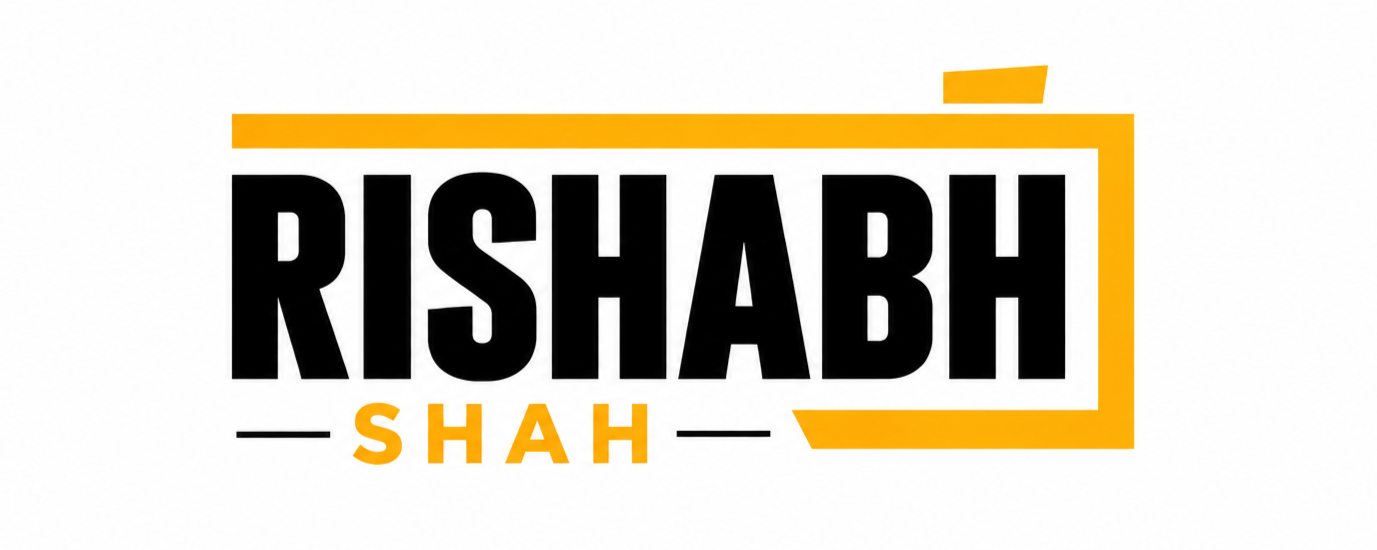

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

PART A — IMAGE UPLOAD & PREPROCESSING

In [ ]:
print("Upload an image for Hough Transform processing:")

uploaded = files.upload()

filename = list(uploaded.keys())[0]

img = cv2.imread(filename)

if img is None:
    print("Error: Image could not be loaded.")
else:
    print("Image uploaded successfully:", filename)
    print("Image size:", img.shape)

Upload an image for Hough Transform processing:


Saving Building.jpg to Building (1).jpg
Image uploaded successfully: Building (1).jpg
Image size: (626, 1198, 3)


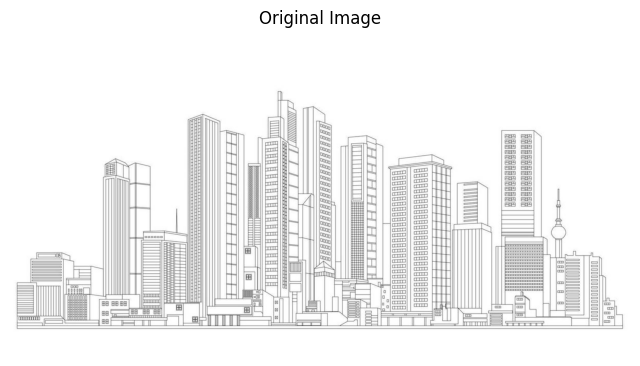

In [ ]:
plt.figure(figsize=(8, 6))

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.show()

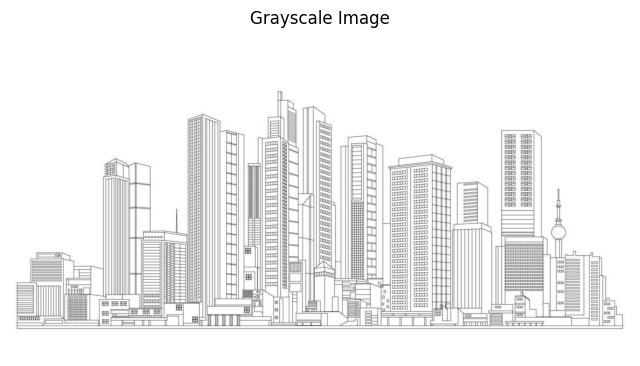

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8, 6))

plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")

plt.show()

TASK 1 — PREPROCESSING

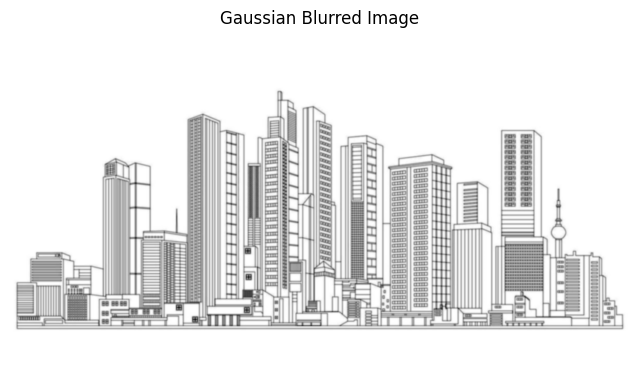

In [ ]:
blur = cv2.GaussianBlur(gray, (5, 5), 0)

plt.figure(figsize=(8, 6))

plt.imshow(blur, cmap='gray')
plt.title("Gaussian Blurred Image")
plt.axis("off")

plt.show()

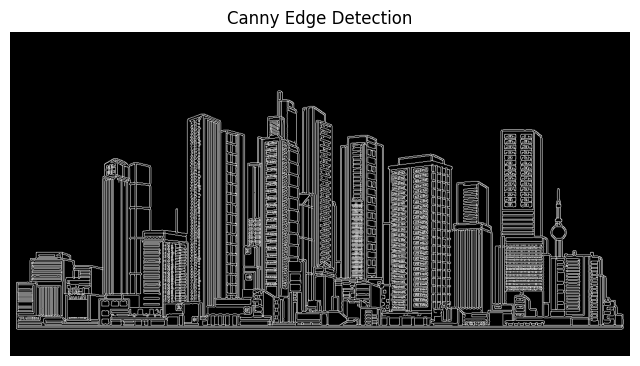

In [ ]:
edges = cv2.Canny(blur, 50, 150)

plt.figure(figsize=(8, 6))

plt.imshow(edges, cmap='gray')
plt.title("Canny Edge Detection")
plt.axis("off")

plt.show()

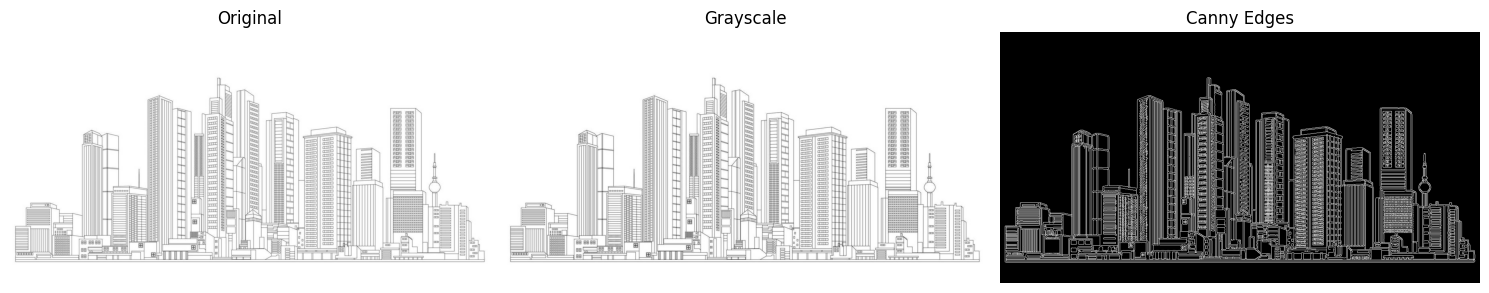

In [ ]:
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")

plt.tight_layout()
plt.show()

TASK 2 — HOUGH LINE DETECTION

In [ ]:
lines = cv2.HoughLines(
    edges,
    1,
    np.pi / 180,
    100
)

result_lines = img.copy()

if lines is not None:

    for line in lines:
        rho, theta = line[0]

        a = np.cos(theta)
        b = np.sin(theta)

        x0 = a * rho
        y0 = b * rho

        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * a)

        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * a)

        cv2.line(
            result_lines,
            (x1, y1),
            (x2, y2),
            (0, 0, 255),
            2
        )

    print("Number of detected lines:", len(lines))

else:
    print("No lines detected.")

Number of detected lines: 14351


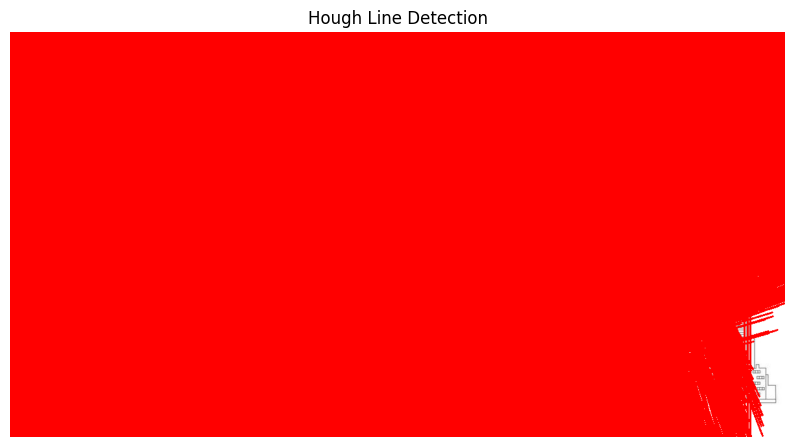

In [ ]:
plt.figure(figsize=(10, 7))

plt.imshow(cv2.cvtColor(result_lines, cv2.COLOR_BGR2RGB))
plt.title("Hough Line Detection")
plt.axis("off")

plt.show()

TASK 2 — PARAMETER EXPERIMENT

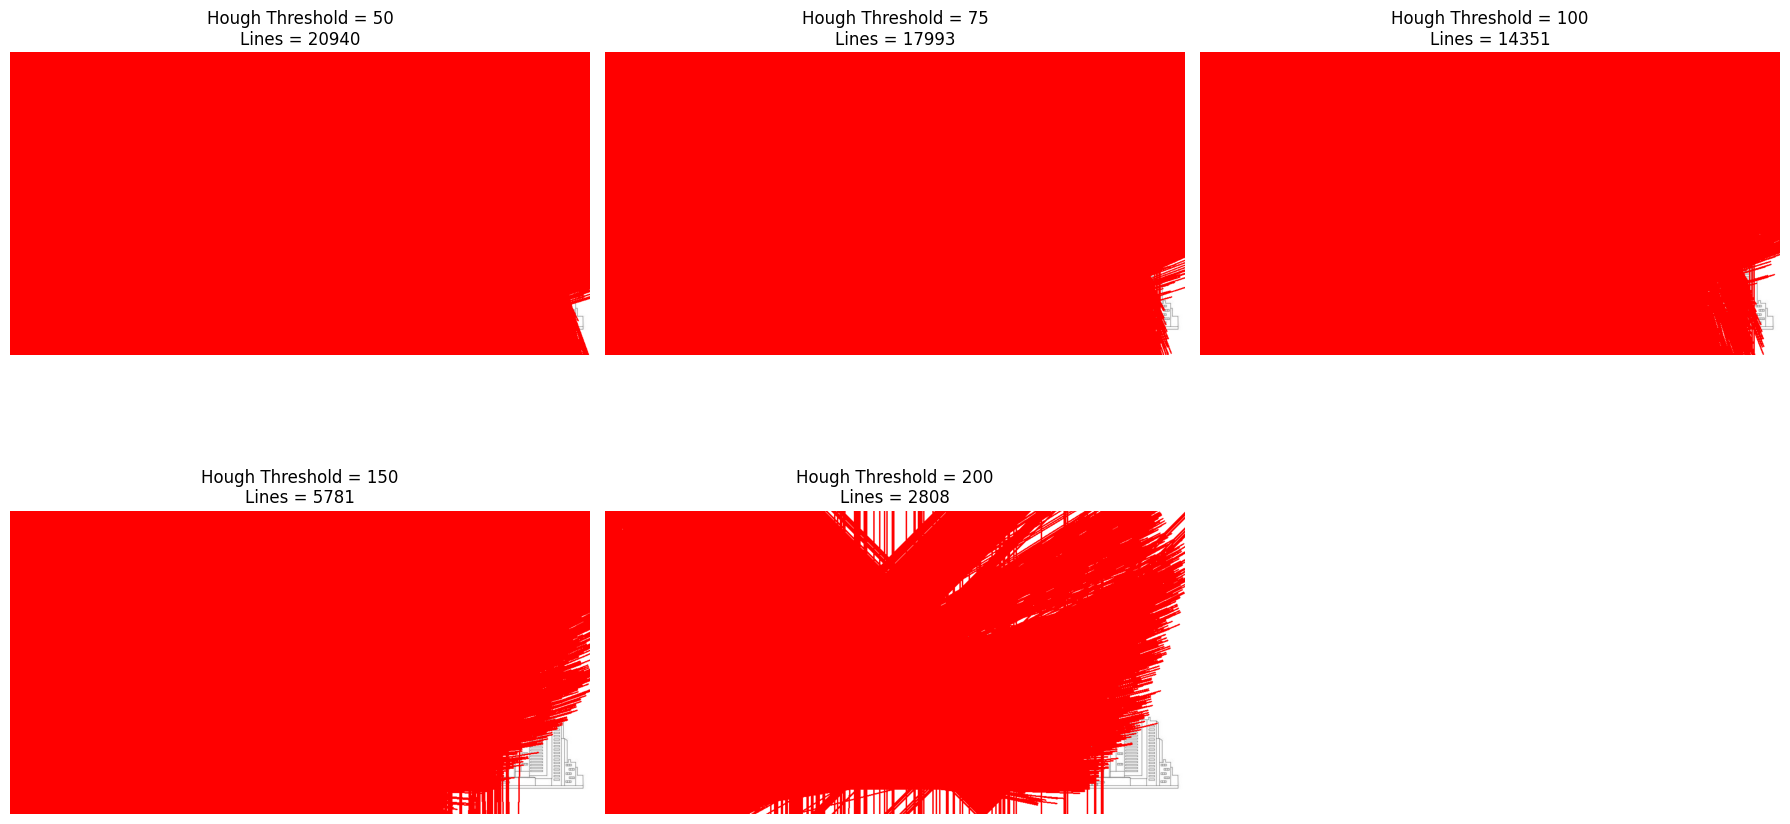

In [ ]:
thresholds = [50, 75, 100, 150, 200]

plt.figure(figsize=(18, 10))

for i, threshold in enumerate(thresholds):

    lines = cv2.HoughLines(
        edges,
        1,
        np.pi / 180,
        threshold
    )

    result = img.copy()

    if lines is not None:

        for line in lines:

            rho, theta = line[0]

            a = np.cos(theta)
            b = np.sin(theta)

            x0 = a * rho
            y0 = b * rho

            x1 = int(x0 + 1000 * (-b))
            y1 = int(y0 + 1000 * a)

            x2 = int(x0 - 1000 * (-b))
            y2 = int(y0 - 1000 * a)

            cv2.line(
                result,
                (x1, y1),
                (x2, y2),
                (0, 0, 255),
                2
            )

        count = len(lines)

    else:
        count = 0

    plt.subplot(2, 3, i + 1)

    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.title(f"Hough Threshold = {threshold}\nLines = {count}")
    plt.axis("off")

plt.tight_layout()
plt.show()

PART B — HOUGH CIRCLE DETECTION

In [ ]:
print("Upload an image containing circular objects:")

uploaded_circle = files.upload()

circle_filename = list(uploaded_circle.keys())[0]

circle_img = cv2.imread(circle_filename)

if circle_img is None:
    print("Error: Circle image could not be loaded.")
else:
    print("Circle image uploaded successfully:", circle_filename)
    print("Image size:", circle_img.shape)

Upload an image containing circular objects:


Saving cars4.jpg to cars4.jpg
Circle image uploaded successfully: cars4.jpg
Image size: (736, 736, 3)


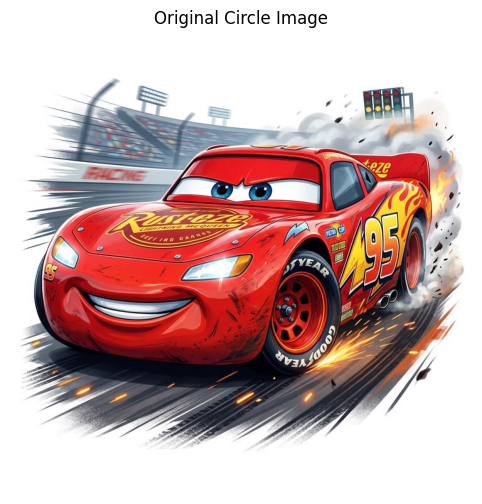

In [ ]:
plt.figure(figsize=(8, 6))

plt.imshow(cv2.cvtColor(circle_img, cv2.COLOR_BGR2RGB))
plt.title("Original Circle Image")
plt.axis("off")

plt.show()

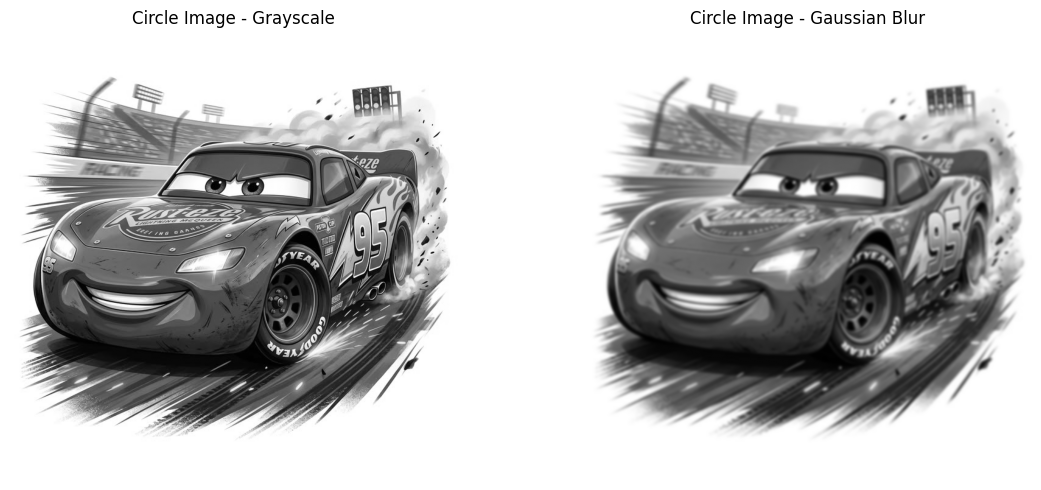

In [ ]:
circle_gray = cv2.cvtColor(
    circle_img,
    cv2.COLOR_BGR2GRAY
)

circle_blur = cv2.GaussianBlur(
    circle_gray,
    (9, 9),
    2
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(circle_gray, cmap="gray")
plt.title("Circle Image - Grayscale")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(circle_blur, cmap="gray")
plt.title("Circle Image - Gaussian Blur")
plt.axis("off")

plt.tight_layout()
plt.show()

TASK 3 — HOUGH CIRCLE DETECTION

In [ ]:
circles = cv2.HoughCircles(
    circle_blur,
    cv2.HOUGH_GRADIENT,
    dp=1,
    minDist=30,
    param1=100,
    param2=30,
    minRadius=10,
    maxRadius=100
)

circle_result = circle_img.copy()

if circles is not None:

    circles = np.uint16(
        np.around(circles)
    )

    print("Number of detected circles:", len(circles[0]))

    for circle in circles[0]:

        x, y, r = circle

        # Draw circle boundary
        cv2.circle(
            circle_result,
            (x, y),
            r,
            (0, 255, 0),
            2
        )

        # Draw center
        cv2.circle(
            circle_result,
            (x, y),
            2,
            (0, 0, 255),
            3
        )

else:

    print("No circles detected.")

Number of detected circles: 80


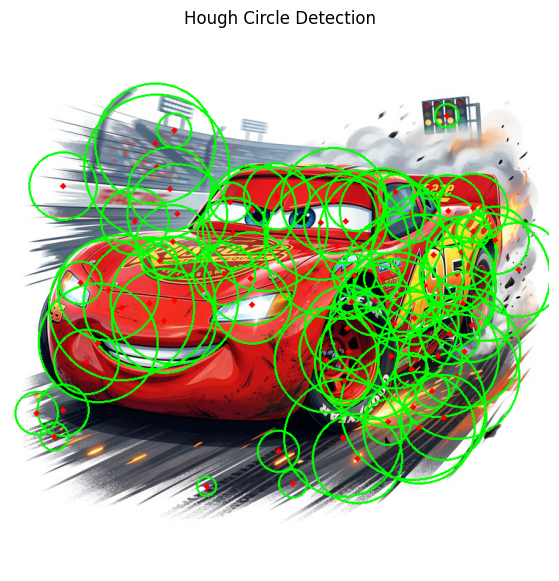

In [ ]:
plt.figure(figsize=(10, 7))

plt.imshow(
    cv2.cvtColor(circle_result, cv2.COLOR_BGR2RGB)
)

plt.title("Hough Circle Detection")
plt.axis("off")

plt.show()

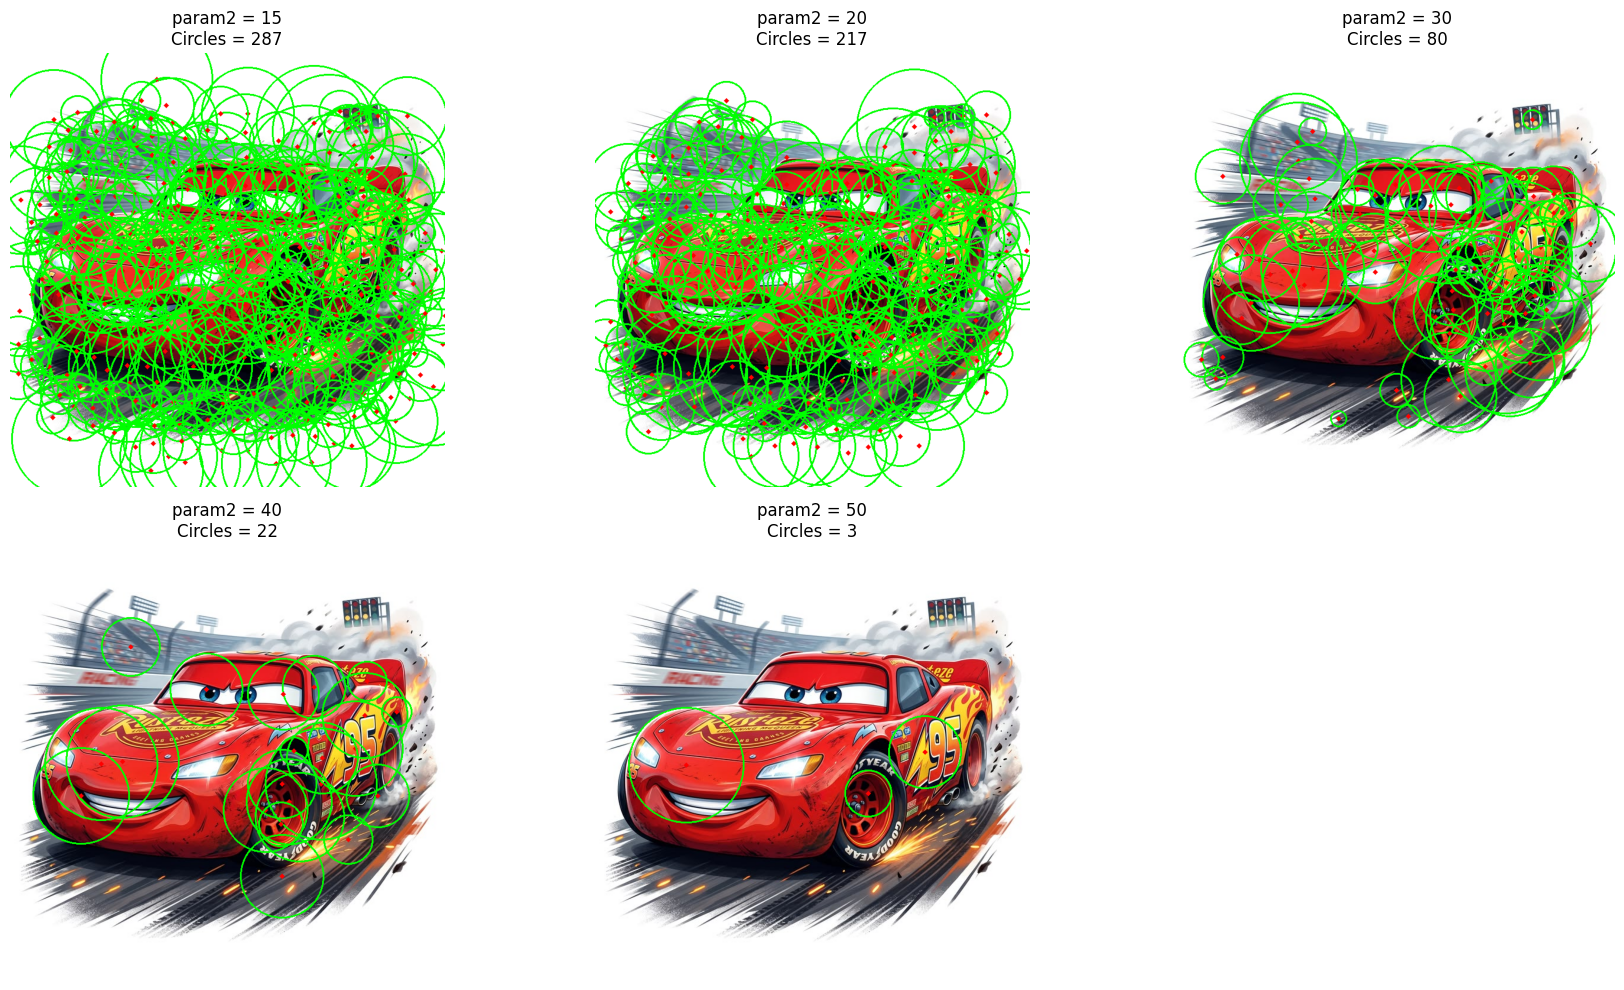

In [ ]:
param2_values = [15, 20, 30, 40, 50]

plt.figure(figsize=(18, 10))

for i, p2 in enumerate(param2_values):

    circles_test = cv2.HoughCircles(
        circle_blur,
        cv2.HOUGH_GRADIENT,
        dp=1,
        minDist=30,
        param1=100,
        param2=p2,
        minRadius=10,
        maxRadius=100
    )

    result = circle_img.copy()

    if circles_test is not None:

        circles_test = np.uint16(
            np.around(circles_test)
        )

        for circle in circles_test[0]:

            x, y, r = circle

            cv2.circle(
                result,
                (x, y),
                r,
                (0, 255, 0),
                2
            )

            cv2.circle(
                result,
                (x, y),
                2,
                (0, 0, 255),
                3
            )

        count = len(circles_test[0])

    else:
        count = 0

    plt.subplot(2, 3, i + 1)

    plt.imshow(
        cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
    )

    plt.title(
        f"param2 = {p2}\nCircles = {count}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

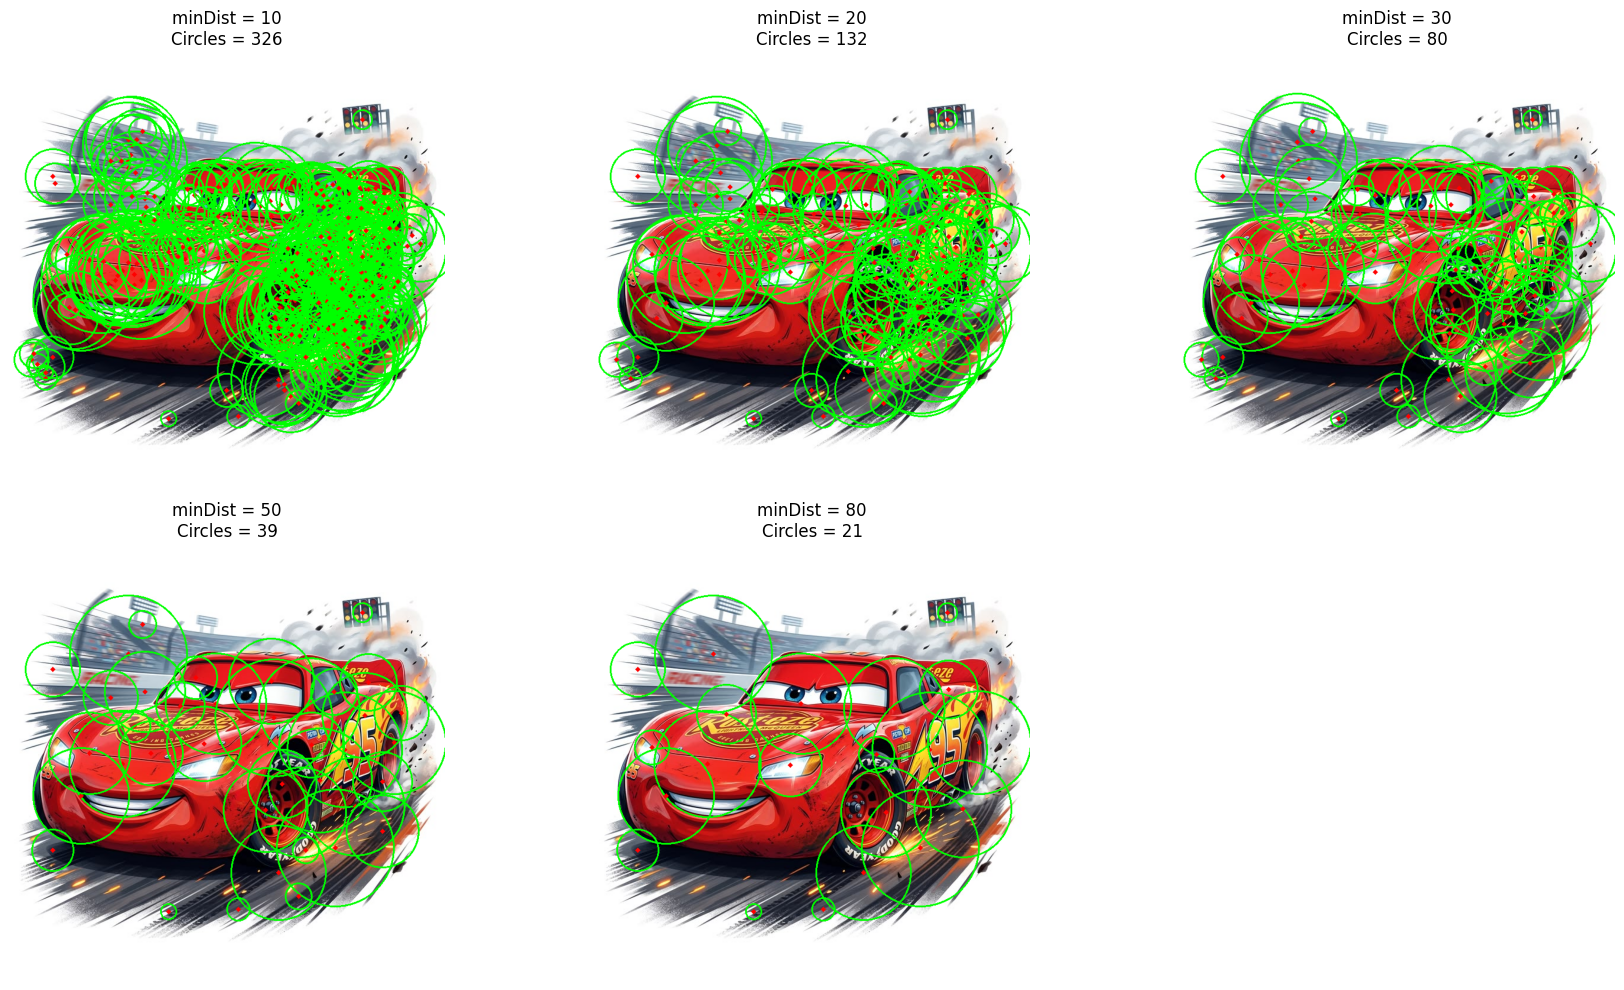

In [ ]:
min_dist_values = [10, 20, 30, 50, 80]

plt.figure(figsize=(18, 10))

for i, distance in enumerate(min_dist_values):

    circles_test = cv2.HoughCircles(
        circle_blur,
        cv2.HOUGH_GRADIENT,
        dp=1,
        minDist=distance,
        param1=100,
        param2=30,
        minRadius=10,
        maxRadius=100
    )

    result = circle_img.copy()

    if circles_test is not None:

        circles_test = np.uint16(
            np.around(circles_test)
        )

        for circle in circles_test[0]:

            x, y, r = circle

            cv2.circle(
                result,
                (x, y),
                r,
                (0, 255, 0),
                2
            )

            cv2.circle(
                result,
                (x, y),
                2,
                (0, 0, 255),
                3
            )

        count = len(circles_test[0])

    else:
        count = 0

    plt.subplot(2, 3, i + 1)

    plt.imshow(
        cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
    )

    plt.title(
        f"minDist = {distance}\nCircles = {count}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
circles_radius = cv2.HoughCircles(
    circle_blur,
    cv2.HOUGH_GRADIENT,
    dp=1,
    minDist=30,
    param1=100,
    param2=30,
    minRadius=10,
    maxRadius=100
)

radius_result = circle_img.copy()

if circles_radius is not None:

    circles_radius = np.uint16(
        np.around(circles_radius)
    )

    for circle in circles_radius[0]:

        x, y, r = circle

        cv2.circle(
            radius_result,
            (x, y),
            r,
            (0, 255, 0),
            2
        )

        cv2.circle(
            radius_result,
            (x, y),
            2,
            (0, 0, 255),
            3
        )

    print(
        "Detected circles:",
        len(circles_radius[0])
    )

else:

    print("No circles detected.")

Detected circles: 80


TASK 5 — REAL-WORLD APPLICATION

In [ ]:
# Detect circles again using selected parameters

circles_final = cv2.HoughCircles(
    circle_blur,
    cv2.HOUGH_GRADIENT,
    dp=1,
    minDist=30,
    param1=100,
    param2=30,
    minRadius=10,
    maxRadius=100
)

final_result = circle_img.copy()

if circles_final is not None:

    circles_final = np.uint16(
        np.around(circles_final)
    )

    circle_count = len(circles_final[0])

    for circle in circles_final[0]:

        x, y, r = circle

        # Circle boundary
        cv2.circle(
            final_result,
            (x, y),
            r,
            (0, 255, 0),
            2
        )

        # Circle center
        cv2.circle(
            final_result,
            (x, y),
            2,
            (0, 0, 255),
            3
        )

    print("Total circular objects detected:", circle_count)

else:

    circle_count = 0

    print("No circular objects detected.")

Total circular objects detected: 80


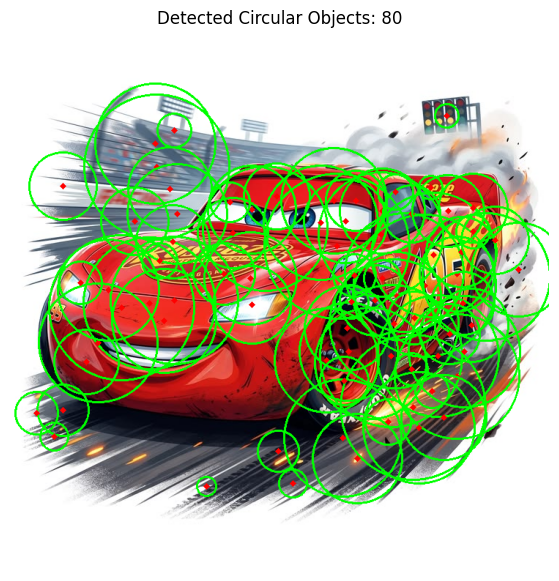

In [ ]:
plt.figure(figsize=(10, 7))

plt.imshow(
    cv2.cvtColor(final_result, cv2.COLOR_BGR2RGB)
)

plt.title(
    f"Detected Circular Objects: {circle_count}"
)

plt.axis("off")

plt.show()

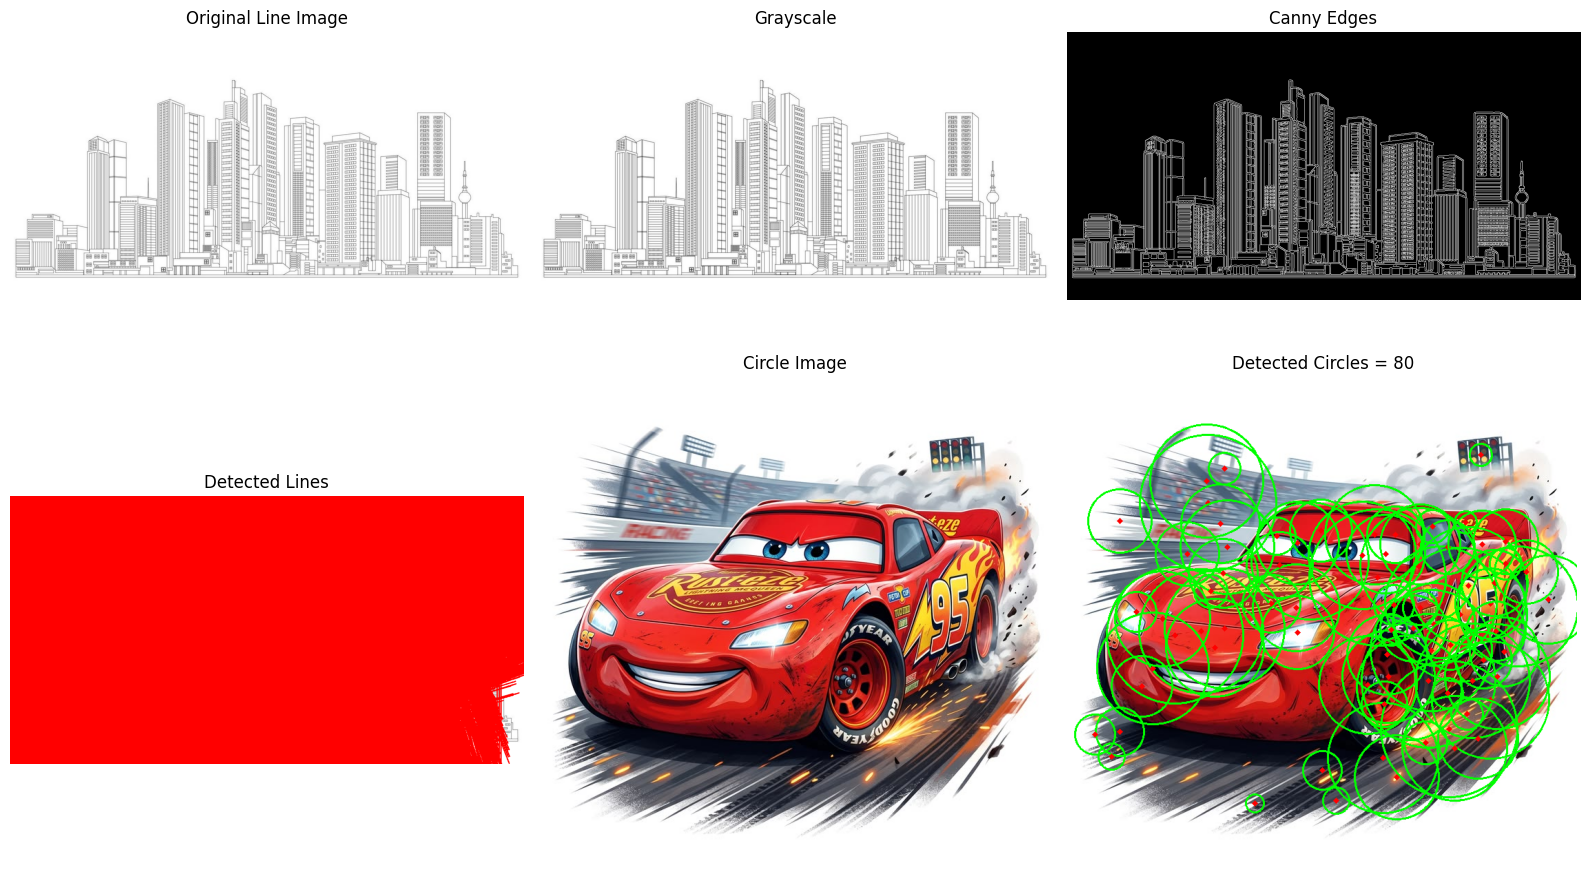

In [ ]:
plt.figure(figsize=(16, 10))

# Original
plt.subplot(2, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Line Image")
plt.axis("off")

# Grayscale
plt.subplot(2, 3, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

# Edges
plt.subplot(2, 3, 3)
plt.imshow(edges, cmap="gray")
plt.title("Canny Edges")
plt.axis("off")

# Lines
plt.subplot(2, 3, 4)
plt.imshow(cv2.cvtColor(result_lines, cv2.COLOR_BGR2RGB))
plt.title("Detected Lines")
plt.axis("off")

# Circle original
plt.subplot(2, 3, 5)
plt.imshow(cv2.cvtColor(circle_img, cv2.COLOR_BGR2RGB))
plt.title("Circle Image")
plt.axis("off")

# Circle result
plt.subplot(2, 3, 6)
plt.imshow(cv2.cvtColor(final_result, cv2.COLOR_BGR2RGB))
plt.title(f"Detected Circles = {circle_count}")
plt.axis("off")

plt.tight_layout()
plt.show()

# Written Answers for the Assignment

**Q1. Why is Gaussian filtering applied before edge detection?**

Gaussian filtering reduces noise and small unwanted details from the image. Noise can create false edges during edge detection. Therefore, smoothing the image helps produce cleaner edges and improves Hough Transform detection.


**Q2. What happens if Canny threshold values are too low?**

Too many weak and noisy edges may be detected. These unwanted edges can result in false line or circle detections.

**Q3. Why might a larger Gaussian kernel be useful for circle detection?**

A larger Gaussian kernel provides more smoothing. It reduces noise and small unwanted edges, which can help the Hough Circle Transform detect circular boundaries more reliably.

**Q4. What happens when the Hough threshold decreases?**

More lines are detected because fewer votes are required for a line to be considered significant.

**Q5. What happens when the Hough threshold increases?**

Fewer lines are detected because only lines receiving a larger number of votes are considered significant.

**Q6. Why do false lines appear?**

False lines can occur due to noise, unwanted edges, textures, object boundaries, and an excessively low Hough threshold.